In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
from scipy.sparse.linalg import LinearOperator, lsqr
import scipy
import time
from scipy.interpolate import lagrange, RegularGridInterpolator
from ader_dg_transport.utils import gll, lagrange1st

from ader_dg_transport.dg_2D import wave_dg_2D, wave_dg_adjoint_2D, wave_dg_optimizer_receiver_2D

import importlib
import os
os.environ["OMP_NUM_THREADS"] = "1"
import scipy.io as sio

In [48]:
data = sio.loadmat('Marmousi_vel.mat')['Marvel']

marmousi = np.copy(data[:, 600:1200])
marmousi[marmousi < 1500] = 1500
xs_ = np.linspace(0, 9_200, data.shape[1])[:marmousi.shape[1]]
xs_ -= xs_.min()
ys_ = np.linspace(0, 3_000, data.shape[0])

interp = RegularGridInterpolator((ys_, xs_), marmousi, method='nearest')

In [94]:
nsteps

584

In [4]:
# data = np.load('marmousi_Ip_model.npy')

# marmousi = data[0, 3_500:3_500+(data.shape[2] - 1)*1 + 1].transpose()

# xs_ = np.arange(marmousi.shape[1]) * 1.25
# ys_ = np.arange(marmousi.shape[0]) * 1.25

# interp = RegularGridInterpolator((ys_, xs_), marmousi, method='nearest')

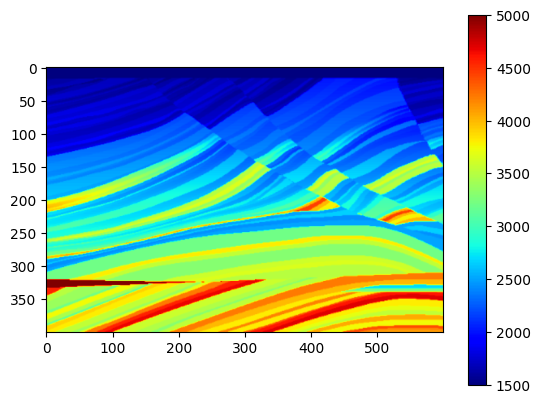

In [49]:
plt.imshow(marmousi, cmap='jet')
plt.colorbar()

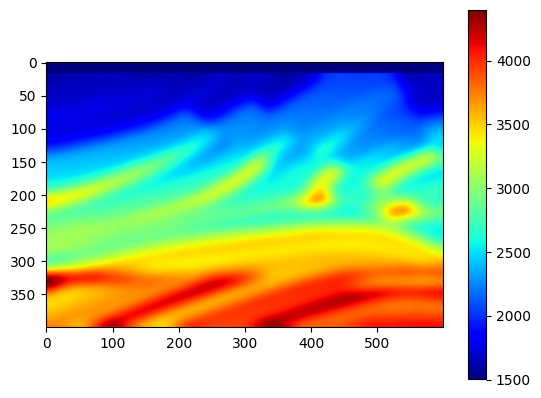

In [63]:
idx = np.where(marmousi[:, 0] > marmousi.min())[0][0]
semi_smooth_marmousi = np.copy(marmousi)
semi_smooth_marmousi[idx:] = scipy.ndimage.gaussian_filter(marmousi[idx:], sigma=10)

semi_smooth_interp = RegularGridInterpolator((ys_, xs_), semi_smooth_marmousi, method='nearest')
plt.imshow(semi_smooth_marmousi, cmap='jet')
plt.colorbar()

In [7]:
# idx = np.where(marmousi[:, 0] > marmousi.min())[0][0]
# smooth_marmousi = np.copy(marmousi)
# smooth_marmousi[idx:] = scipy.ndimage.gaussian_filter(marmousi[idx:], sigma=40)

# smooth_interp = RegularGridInterpolator((ys_, xs_), smooth_marmousi, method='nearest')
# plt.imshow(smooth_marmousi, cmap='jet')
# plt.colorbar()

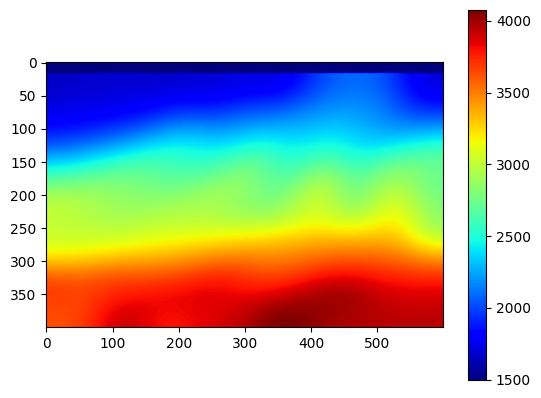

In [52]:
idx = np.where(marmousi[:, 0] > marmousi.min())[0][0]
smooth_marmousi = np.copy(marmousi)
smooth_marmousi[idx:] = scipy.ndimage.gaussian_filter(marmousi[idx:], sigma=30)

smooth_interp = RegularGridInterpolator((ys_, xs_), smooth_marmousi, method='nearest')
plt.imshow(smooth_marmousi, cmap='jet')
plt.colorbar()

In [56]:
xlim = xs_.max()
ylim = ys_.max()


ny = 10
# nx = 1 * ny
nx = 10
c = marmousi.max()

poly_order = 3

dx = xlim / nx
dy = ylim / ny
cfl = 1. / (2 * poly_order + 1)
dt = cfl * min(dx, dy) / c

tend = 5.0

nsteps = int(tend / dt) + 1
dt = tend / nsteps

In [57]:
dy / 3, dx / 3

(np.float64(100.0), np.float64(108.11850107906612))

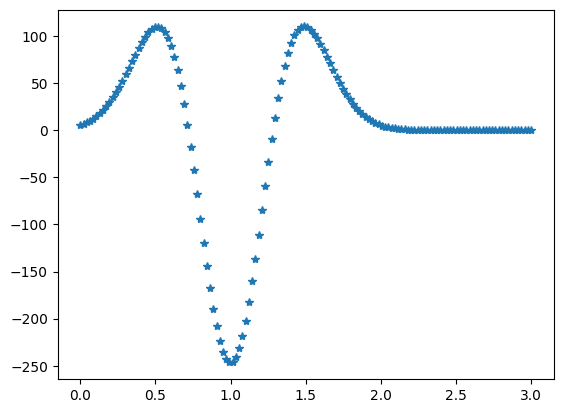

In [93]:
sig = 0.5 * xlim / nx
f0 = 2.5
def F(t, f0):
    return (2 * np.pi * f0)**2 * ((4 * np.pi * (f0 * t - 1)**2) - 1) * np.exp(-2 * np.pi * (f0 * t - 1)**2)


def f(x, y, t, f0):

    
    out = np.zeros(t.shape + (3,) + x.shape)

    out[:, 1] = F(t, f0)[:, None, None, None, None] * np.exp(-((x - 0.5 * xlim)**2 + (y - 0.9 * ylim)**2) / (2 * sig**2))[None]
    return out



# ts = np.linspace(0, 3 / f0, 100)
# forcing = f(xs, ys, ts)

# ts = np.linspace(0, 3 / f0, 100)
# plt.plot(ts * f0, F(ts))

ts = np.linspace(0, 3 / f0, int((3 / f0) / dt))
plt.plot(ts * f0, F(ts, f0=2.5), '*')

# plt.figure()
# plt.tricontourf(xs.ravel(), ys.ravel(), f(xs - 1000, ys, np.array([1 / f0]), f0=2.5)[0, 1].ravel())

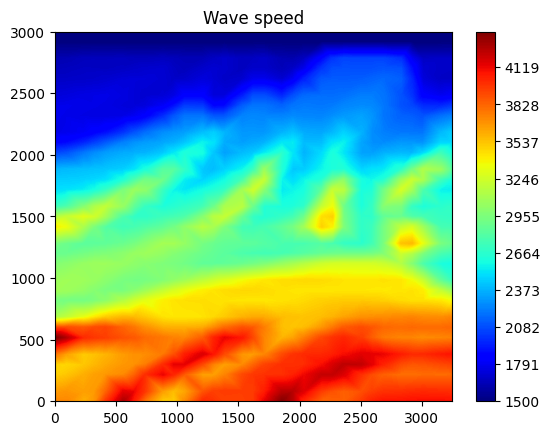

In [64]:
importlib.reload(wave_dg_2D)
importlib.reload(wave_dg_adjoint_2D)

forward_solver = wave_dg_2D.WaveDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
forward_solver.y_periodic = False
forward_solver.x_periodic = False

adjoint_solver = wave_dg_adjoint_2D.WaveAdjointDG2D(xlim, ylim, nx, ny, poly_order=poly_order, c=c, dt=dt)
adjoint_solver.y_periodic = forward_solver.y_periodic
adjoint_solver.x_periodic = forward_solver.x_periodic

xs = forward_solver.xs
ys = forward_solver.ys

pts = np.vstack([ylim - ys.ravel(), xs.ravel()]).transpose()
# c_exact = interp(pts).reshape(forward_solver.c.shape)

c_exact = semi_smooth_interp(pts).reshape(forward_solver.c.shape)

r2 = (xs - (xlim / 2))**2 + (ys - 0.8 * ylim)**2
h0 = np.exp(-r2 / 500**2)

# # forward_solver.c[forward_solver.xs > 5] = 0.5
forward_solver.c[:] = c_exact
adjoint_solver.c[:] = forward_solver.c

plt.title(f'Wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c_exact.ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Get target state

CPU times: user 223 ms, sys: 9.56 ms, total: 232 ms
Wall time: 232 ms


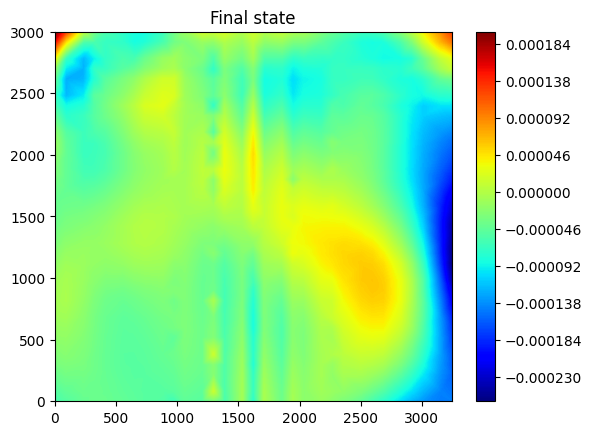

In [65]:
%%time
forward_solver.time = 0.0
forward_solver.state[:] = 0.0
# forward_solver.state[0][:] = h0 * 0
# forward_solver.state[2][:] = h0
forward_solver.cpp = True
forward_solver.c[:] = c_exact

ic_state = np.copy(forward_solver.state)

target_data = np.zeros((nsteps, 3, nx, poly_order + 1))

for i in range(nsteps):
    ts = np.array([forward_solver.time] * 4)
    ts[1] += 0.5 * dt
    ts[2] += dt
    ts[3] += 0.5 * dt
    
    forward_solver.time_step(forcing=f(xs, ys, ts, f0=2.5))
    # forward_solver.time_step()

    target_data[i][:] = forward_solver.state[(slice(None),) + forward_solver.ym_ext]

plt.title(f'Final state')
plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.state[2].ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Optimize

In [66]:
forcing_funcs_lf = [
    lambda x, y, t: f(x - 1000, y, t, f0=2.5),
    lambda x, y, t: f(x - 500, y, t, f0=2.5),
    lambda x, y, t: f(x, y, t, f0=2.5),
    lambda x, y, t: f(x + 500, y, t, f0=2.5),
    lambda x, y, t: f(x + 1000, y, t, f0=2.5),
]

forcing_funcs_hf = [
    lambda x, y, t: f(x - 1000, y, t, f0=5),
    lambda x, y, t: f(x - 500, y, t, f0=5),
    lambda x, y, t: f(x, y, t, f0=5),
    lambda x, y, t: f(x + 500, y, t, f0=5),
    lambda x, y, t: f(x + 1000, y, t, f0=5),
]



In [67]:
target_data_list_lf = [np.zeros((nsteps, 3, nx, poly_order + 1)) for _ in forcing_funcs_lf]

for data, forcing_func in zip(target_data_list_lf, forcing_funcs_lf):
    forward_solver.c[:] = c_exact
    forward_solver.time = 0.0
    forward_solver.state[:] = 0.0
    
    for i in range(nsteps):
    
        ts = np.array([forward_solver.time] * 4)
        ts[1] += 0.5 * dt
        ts[2] += dt
        ts[3] += 0.5 * dt
        
        forward_solver.time_step(forcing=forcing_func(xs, ys, ts))
        # forward_solver.time_step()
    
        data[i][:] = forward_solver.state[(slice(None),) + forward_solver.ym_ext]

# plt.figure()
# plt.title(f'Final condition')
# plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.state[2].ravel(), levels=1000, cmap='jet')
# plt.colorbar()
    

In [68]:
target_data_list_hf = [np.zeros((nsteps, 3, nx, poly_order + 1)) for _ in forcing_funcs_hf]

for data, forcing_func in zip(target_data_list_hf, forcing_funcs_hf):
    forward_solver.c[:] = c_exact
    forward_solver.time = 0.0
    forward_solver.state[:] = 0.0
    
    for i in range(nsteps):
    
        ts = np.array([forward_solver.time] * 4)
        ts[1] += 0.5 * dt
        ts[2] += dt
        ts[3] += 0.5 * dt
        
        forward_solver.time_step(forcing=forcing_func(xs, ys, ts))
        # forward_solver.time_step()
    
        data[i][:] = forward_solver.state[(slice(None),) + forward_solver.ym_ext]

# plt.figure()
# plt.title(f'Final condition')
# plt.tricontourf(xs.ravel(), ys.ravel(), forward_solver.state[2].ravel(), levels=1000, cmap='jet')
# plt.colorbar()

In [69]:
ts = np.arange(1, nsteps + 1) * dt
t_mute = 3.0
tw = np.clip((ts - t_mute)/0.2, 0, 1)

In [70]:
importlib.reload(wave_dg_optimizer_receiver_2D)

optimizers = [wave_dg_optimizer_receiver_2D.WaveDGOptimizerReceiver2D(
    forward_solver, adjoint_solver, ic_state=ic_state, target_data=data, nsteps=nsteps, forcing_func=f, tw=None
) for f, data in zip(forcing_funcs_lf, target_data_list_lf)]

optimizers_hf = [wave_dg_optimizer_receiver_2D.WaveDGOptimizerReceiver2D(
    forward_solver, adjoint_solver, ic_state=ic_state, target_data=data, nsteps=nsteps, forcing_func=f, tw=None
) for f, data in zip(forcing_funcs_hf, target_data_list_hf)]

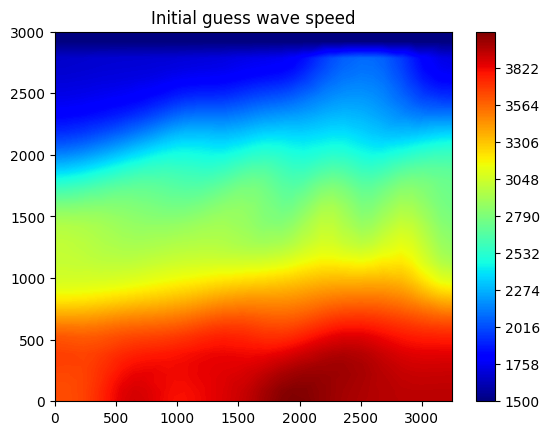

In [71]:
# c0 = np.ones_like(c_true)
# c0 = c_true.mean(axis=(0, 2), keepdims=True) * np.ones_like(np.ones_like(c_true))
c0 = smooth_interp(pts).reshape(forward_solver.c.shape)
# c0 = 1500 - (ys - 3500) * 0.6
c0_w = c0 * optimizers[0].M_half

plt.title(f'Initial guess wave speed')
plt.tricontourf(xs.ravel(), ys.ravel(), c0.ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [72]:
c_water = c_exact.min()
water_mask = (c_exact < c_water)

In [23]:
# c_exact[0, -1, 0, -1]

In [73]:
def fix_wavespeed(c_in):
    c_shape = optimizers[0].forward_solver.c.shape
    c_out = np.copy(c_in.reshape(c_shape))
    c_out[water_mask] = c_water

    return c_out.reshape(c_in.shape)


def fix_wavespeed_w(c_w_in):
    c_shape = optimizers[0].forward_solver.c.shape
    c_in = optimizers[0].M_half_inv * c_w_in.reshape(c_shape)
    c_out = fix_wavespeed(c_in)

    c_w_out = c_out * optimizers[0].M_half

    return c_w_out.reshape(c_w_in.shape)
    

In [74]:
# regularization parameter
# mu = 1e-11
mu = 0.0

def cost_function(c_in):
    c_in = fix_wavespeed(c_in)
    
    c_shape = optimizers[0].forward_solver.c.shape
    penalty = (optimizers[0].M * c_in.reshape(c_shape)**2).sum()
    return sum(optimizer.cost_function(c_in) for optimizer in optimizers) + 0.5 * mu * penalty


def jac_function(c_in):
    c_in = fix_wavespeed(c_in)
    
    c_shape = optimizers[0].forward_solver.c.shape
    penalty = (optimizers[0].M * c_in.reshape(c_shape)).ravel()
    out = sum(optimizer.jac_function(c_in) for optimizer in optimizers) + mu * penalty
    out = out.reshape(c_shape)
    out[water_mask] = 0.0
    return out.ravel()

In [75]:
dc = np.random.random(c_exact.shape)
dc_w = dc * optimizers[0].M_half

In [81]:
# check accuracy of gradient
eps = 1e-8
dcost = optimizers[0].cost_function(c0 + 0.5 * eps * dc) - optimizers[0].cost_function(c0 - 0.5 * eps * dc)
dcostdc = optimizers[0].jac_function(c0)
rel_error = abs((dcost - (dcostdc * dc.ravel() * eps).sum()) / dcost)
print(dcost)
print((dcostdc * dc.ravel() * eps).sum())
print('Rel error:', rel_error)

5.244288331596181e-06
5.244265954402355e-06
Rel error: 4.2669648217199265e-06


In [79]:
def cost_function_w(c_w_in, optimizers=optimizers):
    c_w_in = fix_wavespeed_w(c_w_in)
    penalty = (c_w_in**2).sum()
    return sum(optimizer.cost_function_w(c_w_in) for optimizer in optimizers) + 0.5 * mu * penalty


def jac_function_w(c_w_in, optimizers=optimizers):
    c_w_in = fix_wavespeed_w(c_w_in)
    out = sum(optimizer.jac_function_w(c_w_in) for optimizer in optimizers) + mu * c_w_in.ravel()

    c_shape = optimizers[0].forward_solver.c.shape
    out = out.reshape(c_shape)
    out[water_mask] = 0.0
    return out.ravel() 


def hessp_w(c_w_in, dc_w):
    return sum(optimizer.hessp_w(c_w_in, dc_w) for optimizer in optimizers) + mu * dc_w.ravel()


In [80]:
# check accuracy of gradient
eps = 1e-7
dcost = cost_function_w(c0_w + 0.5 * eps * dc_w) - cost_function_w(c0_w - 0.5 * eps * dc_w)
dcostdc_w = jac_function_w(c0_w)
print(dcost)
print((dcostdc_w * dc_w.ravel() * eps).sum())

0.0006351310876198113
0.0006351318343354878


In [89]:
eps = 1e-3
c_exact_w = c_exact * optimizers[0].M_half

dcost = cost_function_w(c_exact_w + eps * dc_w) - 2 * cost_function_w(c_exact_w) + cost_function_w(c_exact_w - eps * dc_w)

hess_dc = hessp_w(c_exact_w, eps * dc_w)
dcost_est = (hess_dc * eps * dc_w.ravel()).sum()

print(dcost)
print(dcost_est)

0.0002602003294651001
0.0002602003294566403


In [83]:
def cost_function_inv(c_inv):
    c_in = fix_wavespeed(1 / c_inv)
    c_shape = optimizers[0].forward_solver.c.shape
    penalty = (optimizers[0].M * c_in.reshape(c_shape)**2).sum()
    return sum(optimizer.cost_function(c_in) for optimizer in optimizers) + 0.5 * mu * penalty


def jac_function_inv(c_inv):
    c_in = fix_wavespeed(1 / c_inv)
    
    c_shape = optimizers[0].forward_solver.c.shape
    penalty = (optimizers[0].M * c_in.reshape(c_shape)).ravel()
    out = sum(optimizer.jac_function(c_in) for optimizer in optimizers) + mu * penalty
    out = out.reshape(c_shape)
    out[water_mask] = 0.0
    return -out.ravel() / (c_inv**2).ravel()

In [85]:
# # check accuracy of gradient
# dc_inv = 1 / (c0 + 0.5 * eps * dc) - 1 / (c0 - 0.5 * eps * dc)

# dcost = cost_function_inv(c0_inv + 0.5 * dc_inv) - cost_function_inv(c0_inv - 0.5 * dc_inv)
# dcostdc_inv = jac_function_inv(c0_inv)
# print(dcost)
# print((dcostdc_inv * dc_inv.ravel()).sum())
# print((dcostdc * dc.ravel() * eps).sum())

In [86]:
# check exact adjoints
v1 = np.random.random(forward_solver.c.shape)
v2 = np.random.random(target_data[:, :2].shape)

In [87]:
forward_solver.cpp = True
adjoint_solver.cpp = True
out1 = optimizers[0].G_matvec(v1)
out2 = optimizers[0].G_rmatvec(v2)

print((v1.ravel() * out2).sum())
print((v2.ravel() * out1).sum())

0.02459685187115952
0.024596851871159335


In [335]:
# forward_solver.cpp = False
# adjoint_solver.cpp = False
# out1 = optimizers[0].G_matvec(v1)
# out2 = optimizers[0].G_rmatvec(v2)

# print((v1.ravel() * out2).sum())
# print((v2.ravel() * out1).sum())

In [88]:
# error = optimizer.error(c0, fill_gradient=True)
c_error = c0 - c_exact

final_state_norm = sum(0.5 * (optimizers[0].W * opt.target_data**2).sum() for opt in optimizers)

c_norm = 0.5 * (c_exact**2 * optimizers[0].M).sum()

print('Final state error:', cost_function(c0) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c0)
print('||dedc||:', np.linalg.norm(dedc))

Final state error: 0.0020131793412553243
Wave speed (c) RMSE: 99.17096349399567 m/s
||dedc||: 1322.1276580062656


In [437]:
# plt.tricontourf(xs.ravel(), ys.ravel(), abs(dedc).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

Final state error: 2.8876099227132596e-05
Wave speed (c) RMSE: 93.04997326282195 m/s
||dedc||: 19.999719865133745
CPU times: user 1min 24s, sys: 8.67 s, total: 1min 33s
Wall time: 1min 15s


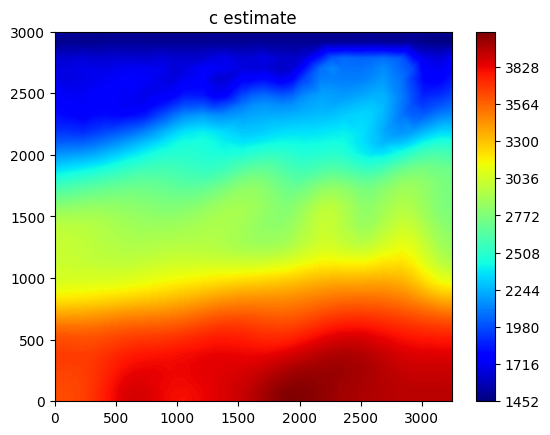

In [89]:
%%time
options = {
    'maxiter': 20,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c0 * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [90]:
cost_function_w_hf = lambda c: cost_function_w(c, optimizers=optimizers_hf)
jac_function_w_hf = lambda c: jac_function_w(c, optimizers=optimizers_hf)
print('Final state error:', cost_function_w_hf(c_est * optimizers[0].M_half) / final_state_norm)


Final state error: 0.00018906172146026113


Final state error: 6.789460551556291e-05
Wave speed (c) RMSE: 88.28215435061527 m/s
||dedc||: 17.23180702834515
CPU times: user 1min 19s, sys: 9.43 s, total: 1min 28s
Wall time: 1min 11s


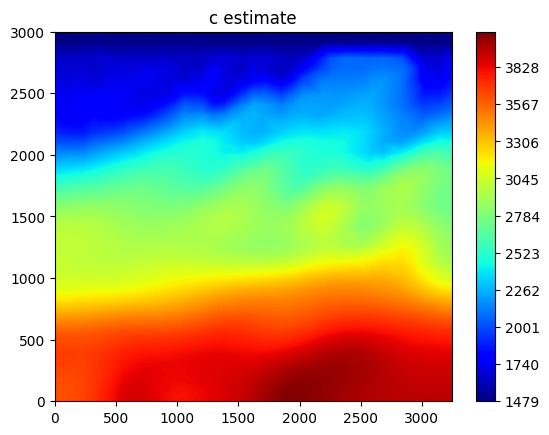

In [91]:
%%time
options = {
    'maxiter': 20,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w_hf, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w_hf, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function_w_hf(c_est * optimizers[0].M_half) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 2.3082194436331422e-05
Wave speed (c) RMSE: 718.343742134449 m/s
||dedc||: 17.020374177415018
CPU times: user 2min 55s, sys: 9.86 s, total: 3min 5s
Wall time: 2min 49s


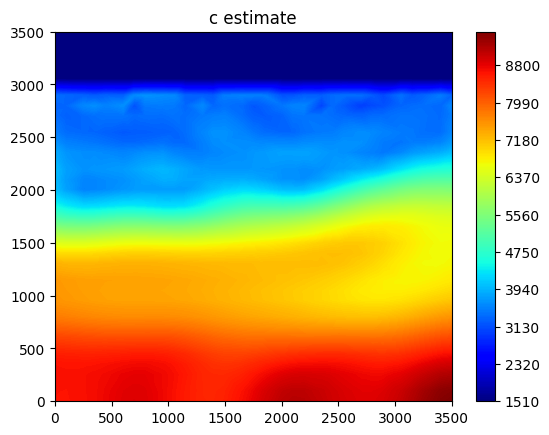

In [444]:
%%time
options = {
    'maxiter': 20,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w_hf, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w_hf, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function_w_hf(c_est * optimizers[0].M_half) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 3.3648934846203284e-05
Wave speed (c) RMSE: 723.6944637942187 m/s


Locator attempting to generate 1000 ticks ([1512.0, ..., 9504.0]), which exceeds Locator.MAXTICKS (1000).


||dedc||: 57.89401747073076
CPU times: user 2min 38s, sys: 6.59 s, total: 2min 44s
Wall time: 2min 27s


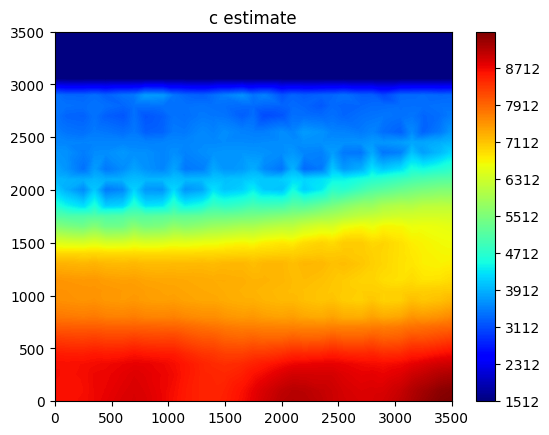

In [352]:
%%time
options = {
    'maxiter': 20,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function, c0.ravel(), jac=jac_function, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

/Users/u5824685/Documents/repos/ader-dg-transport/ader_dg_transport/dg_2D/wave_dg_optimizer_receiver_2D.py:79: RuntimeWarning: overflow encountered in square
  return 0.5 * (error**2 * self.W).sum()
/Users/u5824685/Documents/repos/ader-dg-transport/ader_dg_transport/dg_2D/wave_dg_optimizer_receiver_2D.py:79: RuntimeWarning: overflow encountered in multiply
  return 0.5 * (error**2 * self.W).sum()
/Users/u5824685/Documents/repos/ader-dg-transport/ader_dg_transport/dg_2D/wave_dg_2D.py:156: RuntimeWarning: invalid value encountered in subtract
  dstatedt[(slice(None),) + ip] = dstatedt_p


Final state error: 0.5541045404993712
Wave speed (c) RMSE: 4325.269710825741 m/s
||dedc||: 8219.944671693145
CPU times: user 1min 1s, sys: 1.86 s, total: 1min 3s
Wall time: 1min 3s


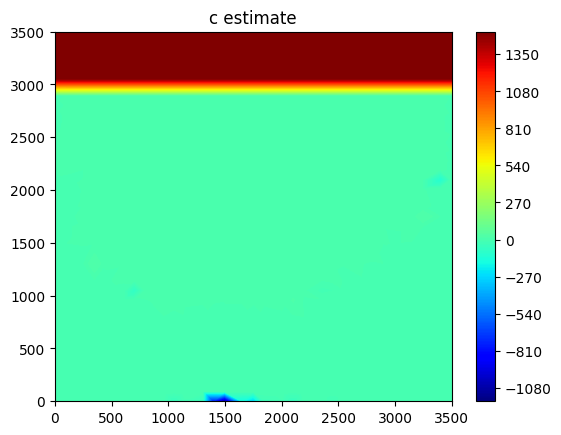

In [385]:
%%time
options = {
    'maxiter': 20,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_inv, (1 / c0).ravel(), jac=jac_function_inv, method='L-BFGS-B', options=options
)

c_est = 1 / result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.554580522410288
Wave speed (c) RMSE: 4331.470354450251 m/s
||dedc||: 11437.885660098662


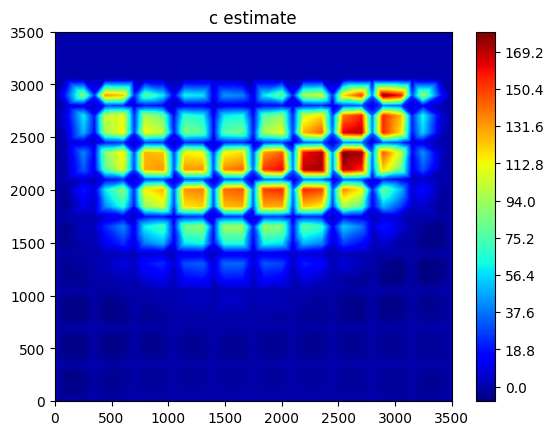

In [387]:
c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 3.8471391933672235e-05
Wave speed (c) RMSE: 722.0536794837543 m/s


Locator attempting to generate 1000 ticks ([1512.0, ..., 9504.0]), which exceeds Locator.MAXTICKS (1000).


||dedc||: 44.47397999358761
CPU times: user 1min 45s, sys: 3.55 s, total: 1min 49s
Wall time: 1min 43s


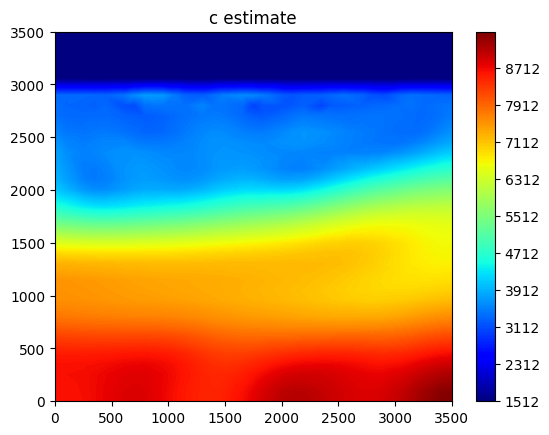

In [348]:
%%time
options = {
    'maxiter': 10,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 2.6485780075763372e-05
Wave speed (c) RMSE: 732.0906207799385 m/s
||dedc||: 0.8610345907723779
CPU times: user 3min 51s, sys: 14.5 s, total: 4min 5s
Wall time: 3min 37s


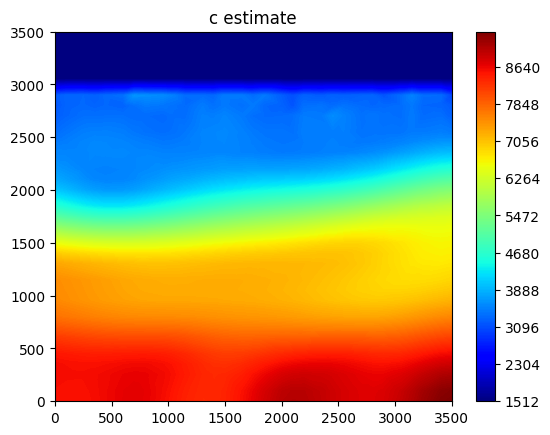

In [242]:
%%time
options = {
    'maxiter': 30,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [243]:
c_exact.size

1600

In [256]:
abs(target_data[:, :, 2]).max()

np.float64(0.9505897576254322)

Final state error: 1.9754891484563858e-05
Wave speed (c) RMSE: 740.3457674857684 m/s
||dedc||: 4.325422918244618
CPU times: user 4min 8s, sys: 15.8 s, total: 4min 24s
Wall time: 4min 1s


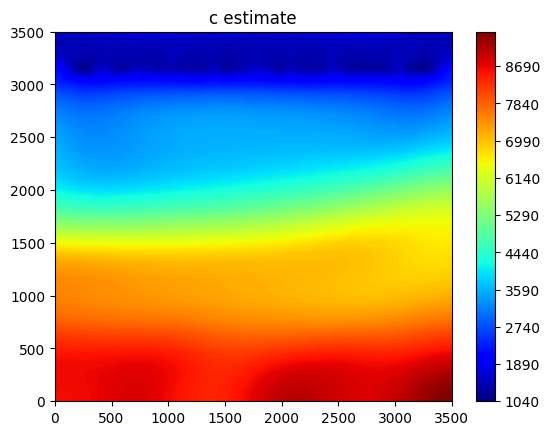

In [158]:
%%time
options = {
    'maxiter': 30,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * optimizers[0].M).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.0001674346407252203
Wave speed (c) RMSE: 274.76635812365316 m/s
||dedc||: 913.9161167853205
CPU times: user 5min 47s, sys: 30.2 s, total: 6min 17s
Wall time: 5min 27s


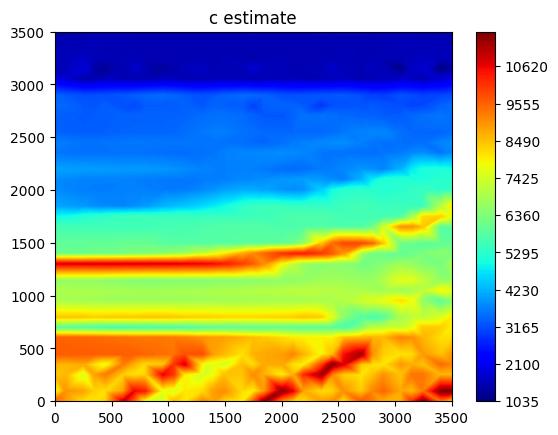

In [470]:
%%time
options = {
    'maxiter': 50,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) RMSE:', np.sqrt(0.5 * (c_error**2 * weights).sum() / (xlim * ylim)), 'm/s')

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [460]:
abs(c_error).mean()

np.float64(234.28176304394344)

In [455]:
c_error.shape

(10, 10, 4, 4)

In [454]:
weights.sum() * nx * ny / (xlim * ylim)

np.float64(1.0000000000000002)

In [371]:
c_w = c_est * optimizers[0].M_half
grad = optimizers[0].jac_function_w(c_w)
hess_dc = optimizers[0].hessp_w(c_w, dc_w)

In [397]:
eps = 5e1
dcost = optimizers[0].cost_function_w(c_w + eps * dc_w) - optimizers[0].cost_function_w(c_w)

In [403]:
dcost_est_linear = (grad * eps * dc_w.ravel()).sum()
dcost_est_quad = dcost_est_linear + 0.5 * eps**2 * (dc_w.ravel() * hess_dc).sum()

print(dcost)
print('Linear rel error:', abs((dcost_est_linear - dcost) / dcost))
print('Quad rel error:', abs((dcost_est_quad - dcost) / dcost))

np.linalg.norm(eps * dc_w.ravel()) #/ (xlim * ylim)

3654780.721110828
Linear rel error: 0.9531421382711001
Quad rel error: 0.10171270337486225


np.float64(102116.84483501464)

Final state error: 0.0007032249252176233
Wave speed (c) error: 0.0041485142699825076
||dedc||: 553.4534756355465
CPU times: user 6min 29s, sys: 12.4 s, total: 6min 41s
Wall time: 6min 43s


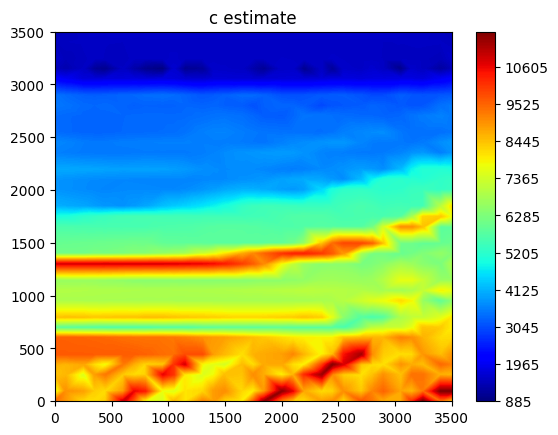

In [401]:
%%time
options = {
    'maxiter': 10,
    'gtol': 1e-6,
    'initial_trust_radius': 102116,
    'max_trust_radius': 102116 * 100
}


result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, 
    method='trust-krylov', options=options, hessp=hessp_w,
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.0003182103519561202
Wave speed (c) error: 0.004053415312403835
||dedc||: 774.1504967384094
CPU times: user 1min 38s, sys: 8.4 s, total: 1min 46s
Wall time: 1min 43s


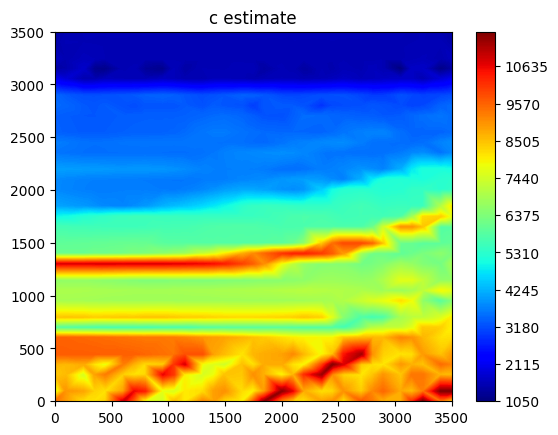

In [412]:
%%time
options = {
    'maxiter': 10,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 4.503780299054882e-05
Wave speed (c) error: 0.0039370743054336806
||dedc||: 214.98930042116146
CPU times: user 5min 38s, sys: 30.2 s, total: 6min 9s
Wall time: 5min 20s


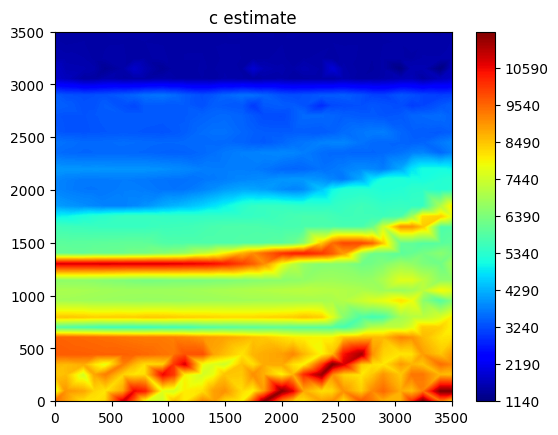

In [413]:
%%time
options = {
    'maxiter': 50,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 1.79102854840363e-05
Wave speed (c) error: 0.00390672885489299
||dedc||: 98.7833333684482
CPU times: user 6min 18s, sys: 40.3 s, total: 6min 58s
Wall time: 6min 15s


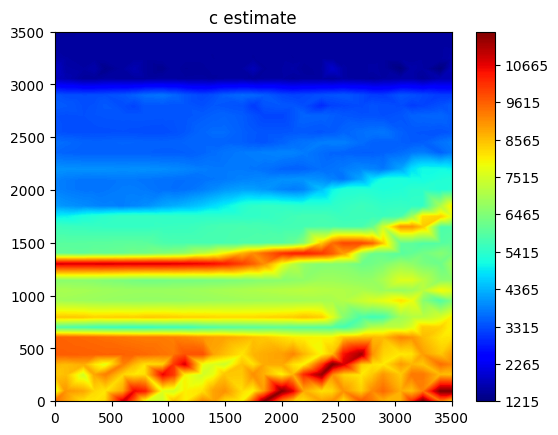

In [430]:
%%time
options = {
    'maxiter': 50,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

result = scipy.optimize.minimize(
    cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [427]:
G = LinearOperator(
    shape=(optimizers[0].target_data.size, optimizers[0].adjoint_solver.c.size),
    matvec=lambda x: sum(opt.G_matvec(x) for opt in optimizers),
    rmatvec=lambda x: sum(opt.G_rmatvec(x) for opt in optimizers),
    dtype=np.float64
)


def optimization_step(c_in, maxiter=40):

    error = sum(opt.error(c_in, fill_gradient=True) for opt in optimizers)

    b = (-error * optimizers[0].W_half).ravel()

    result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=maxiter)
    dc = result[0].reshape(optimizers[0].forward_solver.c.shape) * optimizers[0].M_half_inv

    c_out = c_in + dc

    return c_out

In [431]:
# c_new = optimizers[0].optimization_step(c_est)
c_new = optimization_step(c_est)

Final state error: 2.989222401502925e-05
Wave speed (c) error: 0.0038919433961446125
||dedc||: 1252.872931303259


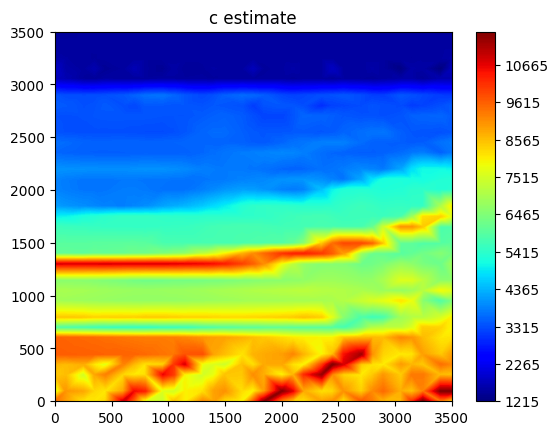

In [432]:
c_error = c_new - c_exact

print('Final state error:', cost_function(c_new) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_new)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_new).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [404]:
c_w = c_est * optimizers[0].M_half
grad = optimizers[0].jac_function_w(c_w)
hess_dc = optimizers[0].hessp_w(c_w, dc_w)

In [407]:
eps = 1e2
dcost = optimizers[0].cost_function_w(c_w + eps * dc_w) - optimizers[0].cost_function_w(c_w)

In [409]:
dcost_est_linear = (grad * eps * dc_w.ravel()).sum()
dcost_est_quad = dcost_est_linear + 0.5 * eps**2 * (dc_w.ravel() * hess_dc).sum()

print(dcost)
print('Linear rel error:', abs((dcost_est_linear - dcost) / dcost))
print('Quad rel error:', abs((dcost_est_quad - dcost) / dcost))

print('Norm:', )
print('Avg wavespeed diff:', np.linalg.norm(eps * dc_w.ravel()) / (xlim * ylim))

12867302.171547802
Linear rel error: 0.9942513961062587
Quad rel error: 0.12058871901594782
Norm:
Avg wavespeed diff: 0.016672137932247286


In [411]:
# %%time
# options = {
#     'maxiter': 40,
#     'gtol': 1e-6,
#     'initial_trust_radius': 102116,
#     'max_trust_radius': 102116 * 100
# }

# result = scipy.optimize.minimize(
#     cost_function_w, (c_est * optimizers[0].M_half).ravel(), jac=jac_function_w, 
#     method='trust-krylov', options=options, hessp=hessp_w,r
# )

# c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
# c_error = c_est - c_exact

# print('Final state error:', cost_function(c_est) / final_state_norm)
# print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

# dedc = jac_function(c_est)
# print('||dedc||:', np.linalg.norm(dedc))

# plt.title(f'c estimate')
# plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

In [ ]:
def hessian_func(c_in_w):
    shape = optimizers[0].forward_solver.c.shape
    c_in = optimizers[0].M_half_inv * c_w_in.reshape(shape)

    out = sum(optimizer.jac_function(c_in) for optimizer in optimizers).reshape(shape)
    

In [301]:
# %%time
# result = scipy.optimize.minimize(
#     cost_function_w, c0_w.ravel(), jac=jac_function_w, method='trust-krylov', options=options
# )

# c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].M_half_inv
# c_error = c_est - c_exact

# print('Final state error:', cost_function(c_est) / final_state_norm)
# print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

# dedc = jac_function(c_est)
# print('||dedc||:', np.linalg.norm(dedc))

# plt.title(f'c estimate')
# plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

In [143]:
step_size = xlim * ylim * 0.005

c_hist = [c0]
errors = [error0]

for i in range(10):
    grad = jac_function_w(c_hist[-1] * optimizers[0].M_half)
    dc_w = step_size * grad / np.linalg.norm(grad)
    dc = dc_w.reshape(c0.shape) * optimizers[0].M_half_inv
    c_new = c_hist[-1] - dc

    error = cost_function(c_new) / final_state_norm

    actual_dec = error - errors[-1]
    pred_dec = -(grad * dc_w).sum() / final_state_norm

    rel_grad_error = abs((actual_dec - pred_dec) / actual_dec)
    
    if error < errors[-1]:
        print(f'Step accepted. Error = {error}')
    
        c_hist.append(c_new)
        errors.append(error)

        if rel_grad_error > 0.5:
            print('Decreasing step size.')
            step_size *= 0.25
        if rel_grad_error < 0.1:
            print('Increasing step size.')
            step_size *= 2
    else:
        print(f'Step rejected. Error = {error}')
        step_size *= 0.25

        


Step accepted. Error = 0.11808909274794258
Step accepted. Error = 0.03234109895756684
Step accepted. Error = 0.02894827653971396
Decreasing step size.
Step accepted. Error = 0.017913658418403422
Step accepted. Error = 0.014305484856737478
Decreasing step size.
Step accepted. Error = 0.013717476771633492
Step accepted. Error = 0.013194896267180668
Step accepted. Error = 0.012714914552439683
Step accepted. Error = 0.01227024041904637


KeyboardInterrupt: 

In [146]:
for i in range(10):
    grad = jac_function_w(c_hist[-1] * optimizers[0].M_half)
    dc_w = step_size * grad / np.linalg.norm(grad)
    dc = dc_w.reshape(c0.shape) * optimizers[0].M_half_inv
    c_new = c_hist[-1] - dc

    error = cost_function(c_new) / final_state_norm

    actual_dec = error - errors[-1]
    pred_dec = -(grad * dc_w).sum() / final_state_norm

    rel_grad_error = abs((actual_dec - pred_dec) / actual_dec)
    
    if error < errors[-1]:
        print(f'Step accepted. Error = {error}')
    
        c_hist.append(c_new)
        errors.append(error)

        if rel_grad_error > 0.5:
            print('Decreasing step size.')
            step_size *= 0.25
        if rel_grad_error < 0.1:
            print('Increasing step size.')
            step_size *= 2
    else:
        print(f'Step rejected. Error = {error}')
        step_size *= 0.25

Step accepted. Error = 0.006142560594602169
Increasing step size.
Step accepted. Error = 0.005855841040390855
Increasing step size.
Step rejected. Error = 0.006145851081084597
Step accepted. Error = 0.005749280822346158
Decreasing step size.
Step accepted. Error = 0.005705001586213573
Step accepted. Error = 0.00566854515571505
Increasing step size.
Step accepted. Error = 0.005598756398620991
Increasing step size.
Step accepted. Error = 0.005461662265291374
Increasing step size.
Step accepted. Error = 0.00522203761405247
Step rejected. Error = 0.0053491719031400296


In [149]:
for i in range(10):
    grad = jac_function_w(c_hist[-1] * optimizers[0].M_half)
    dc_w = step_size * grad / np.linalg.norm(grad)
    dc = dc_w.reshape(c0.shape) * optimizers[0].M_half_inv
    c_new = c_hist[-1] - dc

    error = cost_function(c_new) / final_state_norm

    actual_dec = error - errors[-1]
    pred_dec = -(grad * dc_w).sum() / final_state_norm

    rel_grad_error = abs((actual_dec - pred_dec) / actual_dec)
    
    if error < errors[-1]:
        print(f'Step accepted. Error = {error}')
    
        c_hist.append(c_new)
        errors.append(error)

        if rel_grad_error > 0.5:
            print('Decreasing step size.')
            step_size *= 0.25
        if rel_grad_error < 0.1:
            print('Increasing step size.')
            step_size *= 2
    else:
        print(f'Step rejected. Error = {error}')
        step_size *= 0.25

Step accepted. Error = 0.005155885791832508
Decreasing step size.
Step accepted. Error = 0.005139435518055054
Increasing step size.
Step accepted. Error = 0.005107010641622017
Increasing step size.
Step accepted. Error = 0.00504270117319596
Increasing step size.
Step accepted. Error = 0.004916013337284976
Increasing step size.
Step accepted. Error = 0.004670949766711276
Increasing step size.
Step accepted. Error = 0.00431845083419498
Step rejected. Error = 0.006371818416353326
Step accepted. Error = 0.0041963688947921456
Decreasing step size.
Step accepted. Error = 0.004162434139354776


In [ ]:
# f0 + g^T * g * a + 0.5 * a**2 * (g^T * H * g)
# g^T * g + a * (g^T * H * g) = 0
# a = - g^T * g / (g^T * H * g)
# 

In [148]:
step_size / (xlim * ylim)

np.float64(0.00015625)

In [144]:
pred_dec = -(grad * dc_w).sum() / final_state_norm

rel_grad_error = (actual_dec - pred_dec) / actual_dec


rel_grad_error

np.float64(-0.03815485051246711)

In [137]:
-141301528.360327 / final_state_norm

np.float64(-0.1695683446768934)

In [133]:
(0.011659446298354356 - 0.011382769039515227)

0.00027667725883912843

In [135]:
(grad * dc_w).sum() / final_state_norm

np.float64(0.003702937894505758)

In [113]:
dc_w = step_size * grad / np.linalg.norm(grad)
dc = dc_w.reshape(c0.shape) * optimizers[0].M_half_inv
c_new = c0 - dc

error = cost_function(c_new) / final_state_norm

# print(np.sqrt(((c_new - c0)**2 * weights).sum()) / (xlim * ylim))

In [114]:
error

np.float64(0.03547180761166385)

In [87]:
print(np.sqrt(((c_new - c0)**2 * weights).sum()))
print(np.linalg.norm(dc_w))

2697780.8514187513
1225000.0000000002


In [90]:
1 / optimizers[0].W_half_inv**2

array([[[[ 850.69444444, 4253.47222222, 4253.47222222,  850.69444444]]]])

In [91]:
weights

array([[[[  850.69444444,  4253.47222222,  4253.47222222,
            850.69444444],
         [ 4253.47222222, 21267.36111111, 21267.36111111,
           4253.47222222],
         [ 4253.47222222, 21267.36111111, 21267.36111111,
           4253.47222222],
         [  850.69444444,  4253.47222222,  4253.47222222,
            850.69444444]]]])

In [63]:
options = {
    'maxiter': 100,
    'ftol': 1e-8,
    'gtol': 1e-6,
    'maxcor': 5
}

def scaled_jac_function(c_in):
    out = (jac_function(c_in).reshape(forward_solver.c.shape) / optimizers[0].M).ravel()
    return out

Final state error: 0.0010362293839778906
Wave speed (c) error: 0.00419100331213906
||dedc||: 5041.846353755081
CPU times: user 35min 5s, sys: 52.6 s, total: 35min 57s
Wall time: 35min 15s


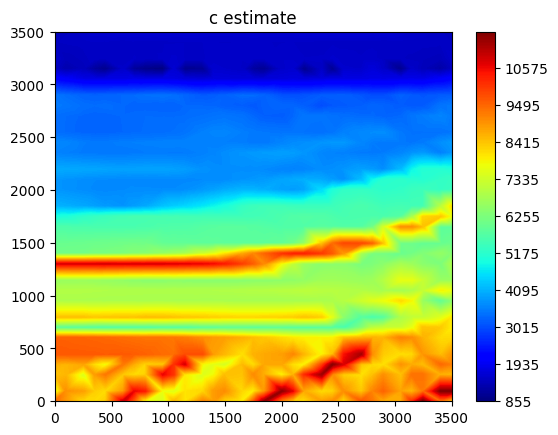

In [72]:
%%time
result = scipy.optimize.minimize(
    cost_function, c0.ravel(), jac=scaled_jac_function, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 7.316605348432532e-05
Wave speed (c) error: 0.003989115275572225
||dedc||: 361.74969956476565
CPU times: user 31min 5s, sys: 1min 19s, total: 32min 24s
Wall time: 30min 41s


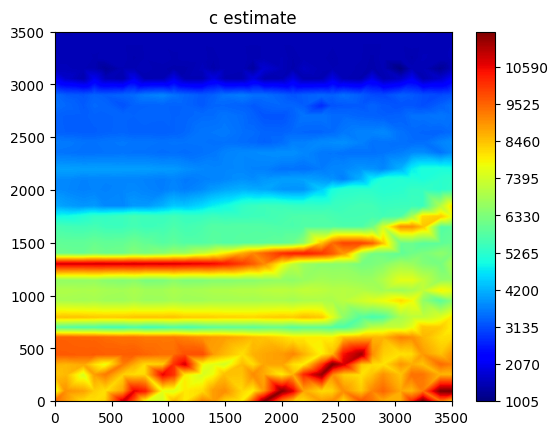

In [73]:
%%time
result = scipy.optimize.minimize(
    cost_function_w, c0_w.ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].W_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 4.2768432638916555e-05
Wave speed (c) error: 0.0039664543391003445
||dedc||: 221.96074579719
CPU times: user 30min 4s, sys: 1min 15s, total: 31min 19s
Wall time: 29min 36s


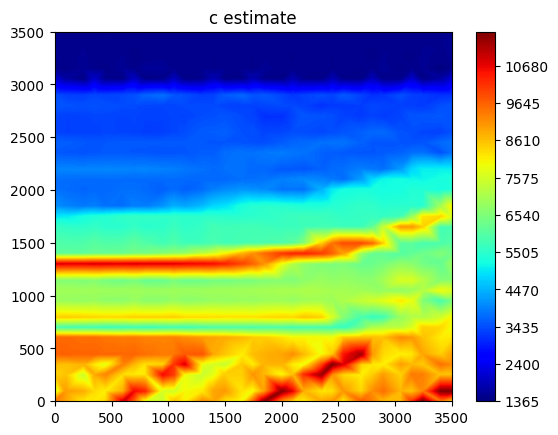

In [74]:
%%time
result = scipy.optimize.minimize(
    cost_function, c0.ravel(), jac=jac_function, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.6272722860727065
Wave speed (c) error: 0.3592343611957601
||dedc||: 85795.55875904857
CPU times: user 3min 6s, sys: 5.5 s, total: 3min 12s
Wall time: 3min 13s


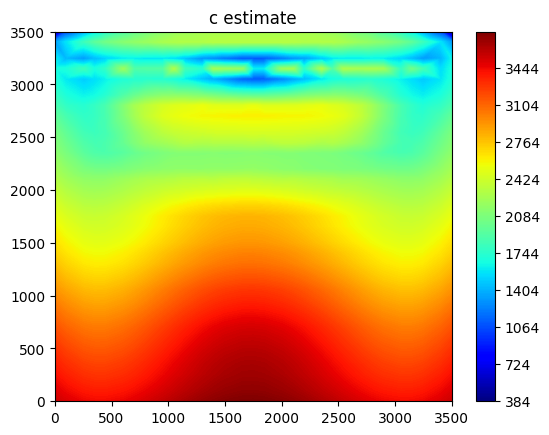

In [64]:
%%time
result = scipy.optimize.minimize(
    cost_function, c0.ravel(), jac=scaled_jac_function, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [65]:
result

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 522706834.75173223
        x: [ 3.547e+03  3.491e+03 ...  1.322e+03  3.877e+02]
      nit: 4
      jac: [ 1.813e-02  1.756e-02 ...  1.085e-01  8.557e-01]
     nfev: 11
     njev: 11
 hess_inv: <1600x1600 LbfgsInvHessProduct with dtype=float64>

Final state error: 0.08214816693920382
Wave speed (c) error: 0.3546017049249787
||dedc||: 14431.892964358725
CPU times: user 47min 22s, sys: 1min 34s, total: 48min 57s
Wall time: 47min 26s


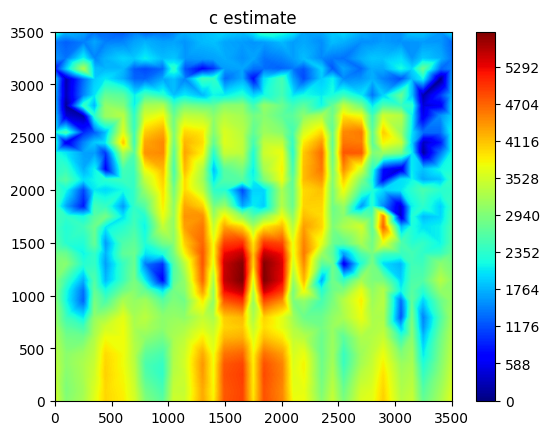

In [66]:
%%time
result = scipy.optimize.minimize(
    cost_function_w, c0_w.ravel(), jac=jac_function_w, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].W_half_inv
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [67]:
c_copy = np.copy(c_est)

Final state error: 0.07403042808412924
Wave speed (c) error: 0.35624386400699365
||dedc||: 17924.185312087113
CPU times: user 45min 17s, sys: 1min 29s, total: 46min 46s
Wall time: 45min 3s


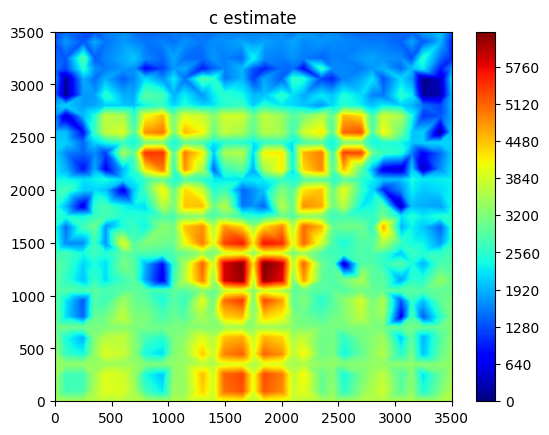

In [68]:
%%time
result = scipy.optimize.minimize(
    cost_function, c0.ravel(), jac=jac_function, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [398]:
# plt.title(f'c estimate')
# plt.tricontourf(xs.ravel(), ys.ravel(), (dedc).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

In [777]:
# plt.semilogy(abs(dedc).reshape(c0.shape).mean(axis=(0, 2)).ravel() / dedc.mean())

In [400]:
# plt.title(f'c estimate')
# plt.tricontourf(xs.ravel(), ys.ravel(), (dedc).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

In [676]:
# plt.semilogy(dedc.reshape(c0.shape).max(axis=(0, 2)).ravel() / dedc.max())

In [402]:
# plt.semilogy(dedc.reshape(c0.shape).max(axis=(0, 2)).ravel() / dedc.max())

In [314]:
# %%time
# result = scipy.optimize.minimize(
#     cost_function_w, c0_w.ravel(), jac=jac_function_w, method='L-BFGS-B', options=dict(maxiter=100)
# )

# c_est = result.x.reshape(forward_solver.c.shape) * optimizers[0].W_half_inv
# error = optimizer.error(c_est, fill_gradient=True)
# c_error = c_est - c_true

# print('Final state error:', cost_function(c_est) / final_state_norm)
# print('Wave speed (c) error:', 0.5 * (c_error**2 * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

# dedc = jac_function(c_est)
# print('||dedc||:', np.linalg.norm(dedc))


In [789]:
# %%time
# result = scipy.optimize.minimize(
#     cost_function, c0.ravel(), jac=jac_function, method='L-BFGS-B', options=options
# )

# c_est = result.x.reshape(forward_solver.c.shape)
# c_error = c_est - c_exact

# print('Final state error:', cost_function(c_est) / final_state_norm)
# print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

# dedc = jac_function(c_est)
# print('||dedc||:', np.linalg.norm(dedc))

# plt.title(f'c estimate')
# plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

Final state error: 0.003318627929327543
Wave speed (c) error: 0.023625905194703273
||dedc||: 7510.096050922712
CPU times: user 12min 15s, sys: 28.4 s, total: 12min 43s
Wall time: 12min 29s


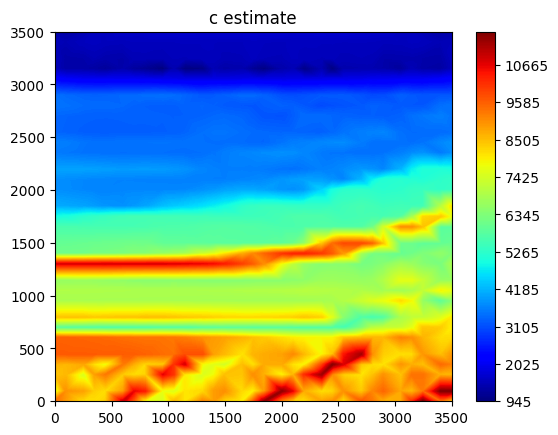

In [793]:
%%time
result = scipy.optimize.minimize(
    cost_function, c0.ravel(), jac=scaled_jac_function, method='L-BFGS-B', options=options
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.36054762687035047
Wave speed (c) error: 0.05186247087775912
||dedc||: 26754.267512185615
CPU times: user 6min 52s, sys: 2min 13s, total: 9min 5s
Wall time: 6min 11s


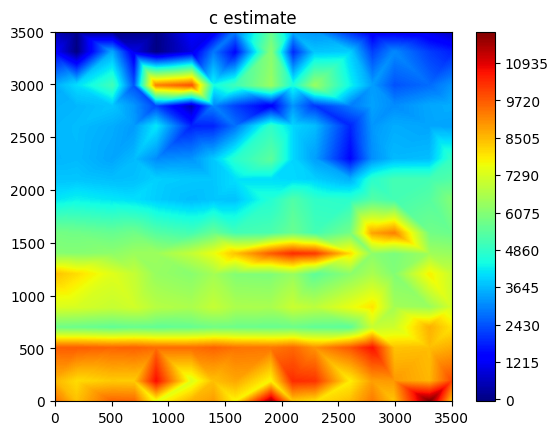

In [683]:
%%time
result = scipy.optimize.minimize(
    cost_function, c_est.ravel(), jac=jac_function, method='L-BFGS-B', options=dict(maxiter=100)
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.33178990383974644
Wave speed (c) error: 0.06500728652367385
||dedc||: 92859.19146898045
CPU times: user 6min 27s, sys: 2min 13s, total: 8min 41s
Wall time: 5min 46s


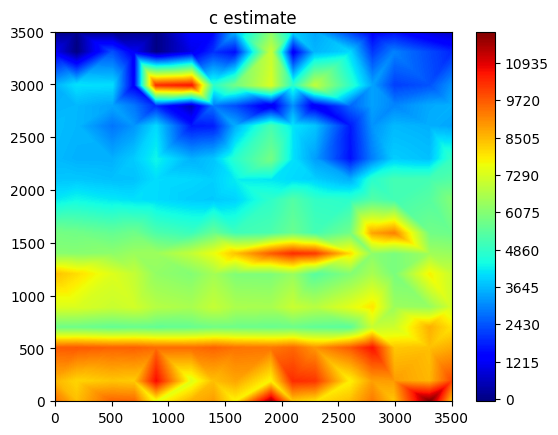

In [684]:
%%time
result = scipy.optimize.minimize(
    cost_function, c_est.ravel(), jac=jac_function, method='L-BFGS-B', options=dict(maxiter=100)
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.3225842204751763
Wave speed (c) error: 0.07193836947838657
||dedc||: 60036.11333464566
CPU times: user 6min 24s, sys: 2min 13s, total: 8min 37s
Wall time: 5min 43s


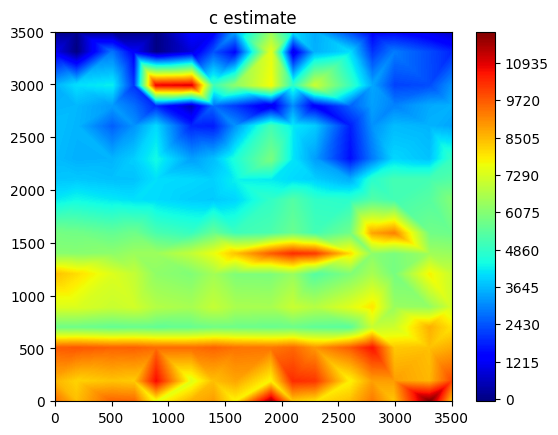

In [685]:
%%time
result = scipy.optimize.minimize(
    cost_function, c_est.ravel(), jac=jac_function, method='L-BFGS-B', options=dict(maxiter=100)
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

In [431]:
%%time
result = scipy.optimize.minimize(
    cost_function, c_est.ravel(), jac=jac_function, method='L-BFGS-B', options=dict(maxiter=100)
)

c_est = result.x.reshape(forward_solver.c.shape)
c_error = c_est - c_exact

print('Final state error:', cost_function(c_est) / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error**2 * weights).sum() / c_norm)

dedc = jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

CPU times: user 4.52 s, sys: 305 ms, total: 4.82 s
Wall time: 4.83 s


KeyboardInterrupt: 

KeyboardInterrupt: 

In [98]:
# dedc = optimizer.jac_function(c_est_init)


In [156]:
# plt.title(f'c estimate')
# plt.tricontourf(xs.ravel(), ys.ravel(), (dedc).ravel(), levels=1000, cmap='jet')
# plt.colorbar()

In [160]:
c_est_init = np.copy(c_est)

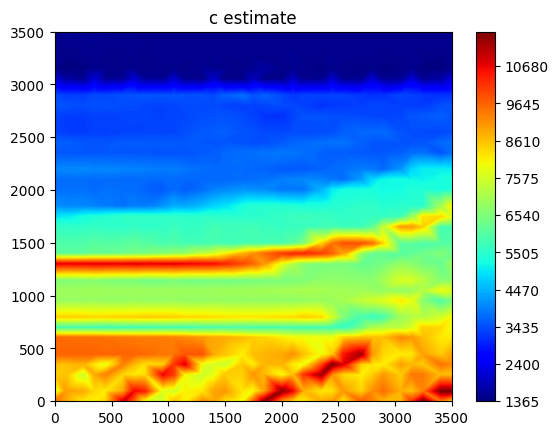

In [162]:
plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est_init).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 0.0004117826332236959
Wave speed (c) error: 0.0039713572005307535
||dedc||: 19597.12762853571
CPU times: user 1min 52s, sys: 2min 13s, total: 4min 5s
Wall time: 1min 12s


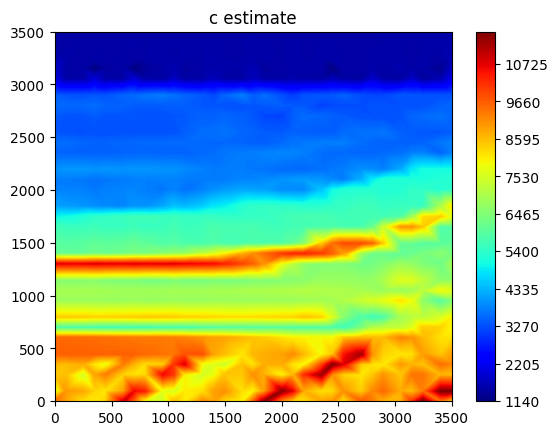

In [161]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=100)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true

print('Final state error:', 0.5 * (weights * error**2).sum() / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()


In [163]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=200)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

CPU times: user 4min 37s, sys: 3min 9s, total: 7min 47s
Wall time: 2min 21s


ValueError: operands could not be broadcast together with shapes (3,10,4) (1,1,4,4) 

Final state error: 4.2578489626297424e-05
Wave speed (c) error: 0.0022230687871795736
||dedc||: 20.91056362585406
CPU times: user 1min 18s, sys: 1.16 s, total: 1min 19s
Wall time: 1min 19s


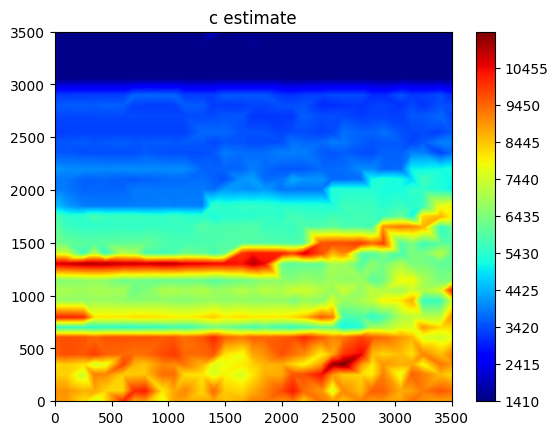

In [190]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=200)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 8.03782326309141e-06
Wave speed (c) error: 0.0014920385513776016
||dedc||: 8.428926056470937
CPU times: user 1min 18s, sys: 1.74 s, total: 1min 20s
Wall time: 1min 20s


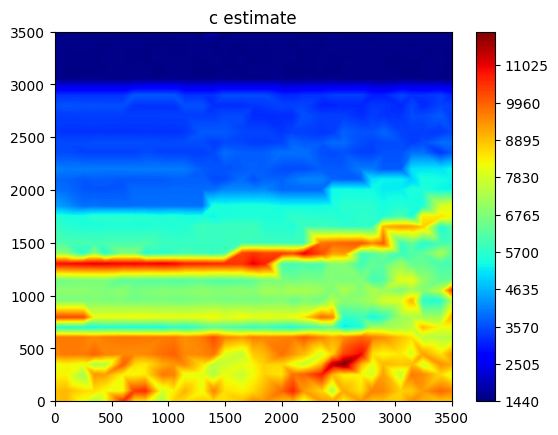

In [191]:
%%time
c_est = optimizer.optimization_step(c_est, maxiter=200)

error = optimizer.error(c_est, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2 / final_state_norm)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25 / c_norm)

dedc = optimizer.jac_function(c_est)
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

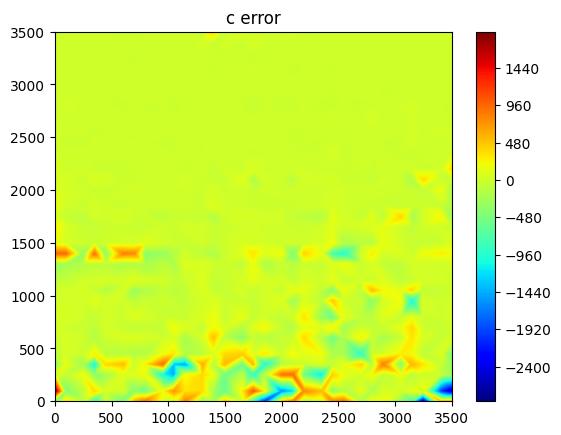

In [192]:
plt.title(f'c error')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_error).ravel(), levels=1000, cmap='jet')
plt.colorbar()

## Optimize

In [ ]:
v1 = np.random.random(forward_solver.c.shape)
v2 = np.random.random(forward_solver.state.shape)

out1 = G_matvec(v1)
out2 = G_rmatvec(v2)

print((v1.ravel() * out2).sum())
print((v2.ravel() * out1).sum())

# Test adjoint

In [10]:
v1 = np.random.random(forward_solver.state.shape)
v2 = np.random.random(forward_solver.state.shape)

In [11]:
forward_solver.cpp = True
adjoint_solver.cpp = True

tmp = np.zeros_like(forward_solver.state)
forward_solver.solve(v1, tmp)
out1 = adjoint_solver.integrate(v2 * tmp)

adjoint_solver.solve(v2, tmp)
out2 = adjoint_solver.integrate(v1 * tmp)

print(out1)
print(out2)

1.4871387521134236
1.4871387521134256


In [12]:
forward_solver.cpp = True
adjoint_solver.cpp = True

forward_solver.state[:] = v1
for _ in range(nsteps):
    forward_solver.time_step()
out1 = forward_solver.integrate(v2 * forward_solver.state)

adjoint_solver.state[:] = v2
for _ in range(nsteps):
    adjoint_solver.time_step()
out2 = adjoint_solver.integrate(v1 * adjoint_solver.state)

print(out1)
print(out2)

75.32145007301754
75.3214500730178


# Test gradient

In [13]:
du0 = np.random.random(forward_solver.state.shape)

In [14]:
reconstructed_ic = np.ones_like(target_ic)
forward_solver.state[:] = reconstructed_ic
for _ in range(nsteps):
    forward_solver.time_step()

error0_ = forward_solver.state - target_state
error0 = 0.5*forward_solver.norm(*forward_solver.get_vars(error0_))**2

In [15]:
eps = 1e-4
forward_solver.state[:] = reconstructed_ic - 0.5 * eps * du0
for _ in range(nsteps):
    forward_solver.time_step()

error1_ = forward_solver.state - target_state
error1 = 0.5*forward_solver.norm(*forward_solver.get_vars(error1_))**2

In [16]:
eps = 1e-4
forward_solver.state[:] = reconstructed_ic + 0.5 * eps * du0
for _ in range(nsteps):
    forward_solver.time_step()

error2_ = forward_solver.state - target_state
error2 = 0.5*forward_solver.norm(*forward_solver.get_vars(error2_))**2

In [17]:
print(error2 - error1)

0.014738131891107287


In [18]:
weights = forward_solver.weights_2D[None, None, None] * forward_solver.dx *  forward_solver.dy * 0.25
print((error0_ * (error2_ - error1_) * weights).sum())

0.014738131891073003


In [19]:
eps = 1e-4
adjoint_solver.state[:] = error0_
for _ in range(nsteps):
    adjoint_solver.time_step()

weights = forward_solver.weights_2D[None, None, None] * forward_solver.dx *  forward_solver.dy * 0.25
print((adjoint_solver.state * eps * du0 * weights).sum())

0.014738131891356922


# Vary c

## Check difference

In [20]:
c0 = np.ones_like(forward_solver.c)


In [21]:
# get gradient data
history_data = np.zeros((nsteps, 4) + forward_solver.state.shape)
forward_solver.state[:] = target_ic
forward_solver.c[:] = c0
adjoint_solver.c[:] = c0

for i in range(nsteps):
    forward_solver.time_step(history_data=history_data[i])

error = forward_solver.state - target_state

In [22]:
dc = np.random.random(c_true.shape)

In [23]:
eps = 1e-6

In [24]:
# vary c and calculate difference
forward_solver.c[:] = c0 - 0.5 * eps * dc
forward_solver.state[:] = target_ic

for _ in range(nsteps):
    forward_solver.time_step()

state1 = np.copy(forward_solver.state)
error1 = 0.5*forward_solver.norm(*forward_solver.get_vars(state1 - target_state))**2

forward_solver.c[:] = c0

In [25]:
forward_solver.c[:] = c0 + 0.5 * eps * dc
forward_solver.state[:] = target_ic

for _ in range(nsteps):
    forward_solver.time_step()

state2 = np.copy(forward_solver.state)
error2 = 0.5*forward_solver.norm(*forward_solver.get_vars(state2 - target_state))**2

forward_solver.c[:] = c0

In [26]:
dstate = state2 - state1

In [27]:
forward_solver.state[:] = 0.0

for i in range(nsteps):
    forward_solver.time_step(forcing=history_data[i] * eps * dc[None, None])

diff_est = np.copy(forward_solver.state)

In [28]:
print(np.linalg.norm(diff_est - dstate) / np.linalg.norm(dstate))

1.8927517712800025e-10


In [29]:
print(error2 - error1)

4.092237712027824e-06


In [30]:
print((error * (state2 - state1) * weights).sum())

4.092237711979067e-06


In [31]:
print((error * forward_solver.state * weights).sum())

4.092237712004551e-06


## Get adjoint

In [32]:
adjoint_data = np.zeros((nsteps, 4) + forward_solver.state.shape)
adjoint_solver.state[:] = error
for i in range(nsteps):
    adjoint_solver.time_step(stage_data=adjoint_data[i])

tmp = (adjoint_data[::-1, ::-1] * history_data).sum(axis=(0, 2)) * 0.5 * adjoint_solver.dt
dedc = (tmp[3] + tmp[2] * (1 / 3) + tmp[1] + tmp[0]) * weights[0]

print((dedc * dc * eps).sum())

4.092237712004557e-06


## Try and optimize

In [33]:
def get_error(c_in, target_state, ic_state, fill_gradient=False):

    forward_solver.state[:] = ic_state
    forward_solver.c[:] = c_in
    adjoint_solver.c[:] = forward_solver.c
    for i in range(nsteps):
        if fill_gradient:
            forward_solver.time_step(history_data=history_data[i])
        else:
            forward_solver.time_step()
       
    error = forward_solver.state - target_state

    return error

In [34]:
W = adjoint_solver.weights_2D[None, None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25
M = adjoint_solver.weights_2D[None, None] * adjoint_solver.dy * adjoint_solver.dx * 0.25

W_half = np.sqrt(W)
M_half = np.sqrt(M)

W_half_inv = 1 / W_half
M_half_inv = 1 / M_half

In [35]:
def G_matvec(dc_vec):
    # 1) reshape u0

    n = forward_solver.poly_order + 1

    dc = dc_vec.reshape((nx, ny, n, n)) * M_half_inv
    forward_solver.state[:] = 0.0
    for i in range(nsteps):
        forward_solver.time_step(forcing=history_data[i] * dc[None, None])
        
    return np.copy(forward_solver.state * W * W_half_inv).ravel()
    # return np.copy(forward_solver.state * W).ravel()


def G_rmatvec(y_vec):
    # y_vec has size m = Nrec*Nt
    data = y_vec.reshape(adjoint_solver.state.shape) * W_half_inv

    adjoint_solver.state[:] = data

    n = forward_solver.poly_order + 1
    out = np.zeros((nx, ny, n, n))
    
    for i in range(nsteps):
        
        adjoint_solver.time_step(stage_data=adjoint_data[i])

    tmp = (adjoint_data[::-1, ::-1] * history_data).sum(axis=(0, 2)) * 0.5 * adjoint_solver.dt
    dedc = (tmp[3] + tmp[2] * (1 / 3) + tmp[1] + tmp[0]) * weights[0]
    
    return (dedc * M_half_inv).ravel()
    # return (dedc).ravel()

In [36]:
G = LinearOperator(
    shape=(target_state.size, c0.size),
    matvec=G_matvec,
    rmatvec=G_rmatvec,
    dtype=np.float64
)


def optimization_step(c_in, target_state, ic_state, maxiter=10):

    error = get_error(c_in, target_state, ic_state, fill_gradient=True)

    b = (-error * W_half).ravel()
    
    result = lsqr(G, b, atol=1e-10, btol=1e-10, iter_lim=maxiter)
    dc = result[0].reshape(c0.shape) * M_half_inv

    c_out = c_in + dc

    return c_out

In [37]:
def cost_function(c_in):
    c_in = c_in.reshape(c0.shape)
    error = get_error(c_in, target_state, target_ic, fill_gradient=False)
    return 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2


def jac_function(c_in):
    c_in = c_in.reshape(forward_solver.c.shape)
    error = get_error(c_in, target_state, target_ic, fill_gradient=True)

    dedc = G_rmatvec(error * W_half).reshape(forward_solver.c.shape) * M_half

    return dedc.ravel()

In [38]:
# dedc.shape

In [39]:
v1 = np.random.random(forward_solver.c.shape)
v2 = np.random.random(forward_solver.state.shape)

out1 = G_matvec(v1)
out2 = G_rmatvec(v2)

print((v1.ravel() * out2).sum())
print((v2.ravel() * out1).sum())

-42.93466712082835
-42.934667120828195


In [40]:
dcost = cost_function(c0 + 0.5 * eps * dc) - cost_function(c0 - 0.5 * eps * dc)

In [41]:
dcost_est = (eps * dc.ravel() * jac_function(c0)).sum()

In [42]:
print(dcost)
print(dcost_est)

4.092237712027824e-06
4.092237712004557e-06


## Optimize!

In [43]:
error = get_error(c0, target_state, target_ic, fill_gradient=True)
c_error = c0 - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))


Final state error: 0.25841680472594347
Wave speed (c) error: 0.25000000000000006
||dedc||: 0.21172383690285365


In [44]:
%%time
result = scipy.optimize.minimize(cost_function, c0.ravel(), jac=jac_function, method='L-BFGS-B', options=dict(maxiter=1000))

CPU times: user 1min 19s, sys: 1min 24s, total: 2min 44s
Wall time: 32.5 s


In [45]:
c_est = result.x.reshape(c0.shape)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

Final state error: 2.656063136253146e-05
Wave speed (c) error: 0.02583943385655221
||dedc||: 0.00014086819535990772


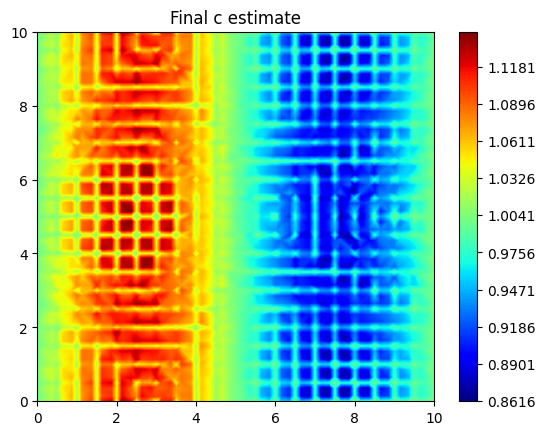

In [46]:
plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 2.880685244455428e-05
Wave speed (c) error: 0.002910287738674041
||dedc||: 0.00361391000430783
CPU times: user 1min 31s, sys: 1min 38s, total: 3min 9s
Wall time: 26.2 s


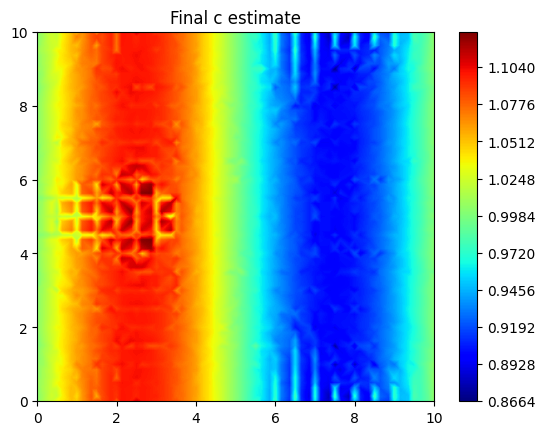

In [47]:
%%time
c_est = optimization_step(c_est, target_state, target_ic, maxiter=100)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 2.607987511737124e-07
Wave speed (c) error: 0.0004055328483904455
||dedc||: 0.00026816579274604926
CPU times: user 2min 45s, sys: 3min 50s, total: 6min 36s
Wall time: 54.9 s


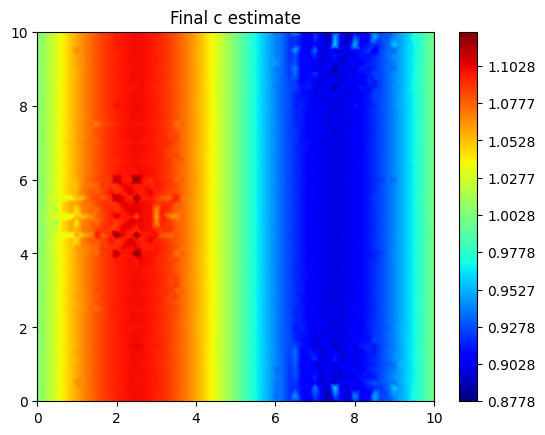

In [48]:
%%time
c_est = optimization_step(c_est, target_state, target_ic, maxiter=200)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()

Final state error: 4.575030095610243e-09
Wave speed (c) error: 0.00011772689934227103
||dedc||: 2.8031473255064897e-05
CPU times: user 2min 20s, sys: 4min 20s, total: 6min 40s
Wall time: 54.9 s


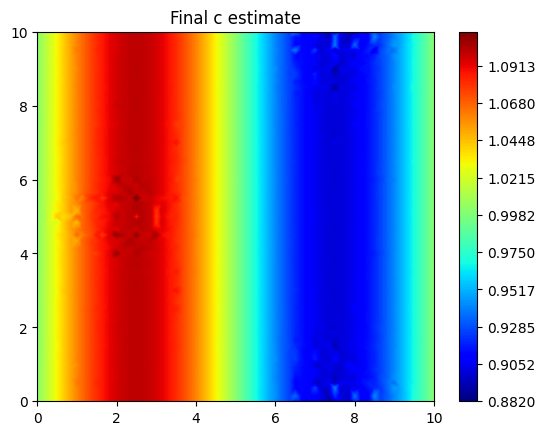

In [49]:
%%time
c_est = optimization_step(c_est, target_state, target_ic, maxiter=200)

error = get_error(c_est, target_state, target_ic, fill_gradient=True)
c_error = c_est - c_true
print('Final state error:', 0.5*forward_solver.norm(*forward_solver.get_vars(error))**2)
print('Wave speed (c) error:', 0.5 * (c_error * c_error * forward_solver.weights_2D[None, None]).sum() * forward_solver.dx * forward_solver.dy * 0.25)

dedc = G_rmatvec(error * W_half).reshape(c0.shape) * M_half
print('||dedc||:', np.linalg.norm(dedc))

plt.title(f'Final c estimate')
plt.tricontourf(xs.ravel(), ys.ravel(), (c_est).ravel(), levels=1000, cmap='jet')
plt.colorbar()